# Visualizing Posterior Circadian Waveforms

This notebook demonstrates how to load the Bayesian temporal regression outputs from our aortic circadian atlas and visualize approximate posterior waveforms for any gene.

The regression outputs are hosted on Zenodo ([doi:10.5281/zenodo.22847203](https://doi.org/10.5281/zenodo.22847203)). This notebook will download them if they are not already present locally.

## 1. Sync data from Zenodo

In [1]:
import os
import hashlib
import urllib.request
import zipfile

DATA_DIR = os.path.expanduser("~/misalignment_data")
ZENODO_RECORD = "22847203"
ZENODO_BASE = f"https://zenodo.org/records/{ZENODO_RECORD}/files"

FILES = {
    "bayesian_regressions_major_cell_types.zip": "bayesian_regressions_major_cell_types",
    "bayesian_regressions_smc_subtypes.zip": "bayesian_regressions_smc_subtypes",
}


def md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def sync_file(zip_name, extract_name):
    """Download and extract a zip if the local copy is missing or differs from Zenodo."""
    zip_path = os.path.join(DATA_DIR, zip_name)
    extract_path = os.path.join(DATA_DIR, extract_name)
    url = f"{ZENODO_BASE}/{zip_name}"

    # Check if we need to download
    need_download = True
    if os.path.exists(zip_path):
        # Compare checksum with Zenodo via HTTP HEAD (Content-MD5 header)
        try:
            req = urllib.request.Request(url, method="HEAD")
            with urllib.request.urlopen(req) as resp:
                remote_md5 = resp.headers.get("Content-MD5", "").strip()
                # Zenodo may also provide ETag as md5
                if not remote_md5:
                    etag = resp.headers.get("ETag", "").strip('"')
                    if len(etag) == 32:
                        remote_md5 = etag
            if remote_md5:
                local_md5 = md5(zip_path)
                if local_md5 == remote_md5:
                    print(f"  {zip_name}: local copy matches Zenodo (md5: {local_md5[:12]}...)")
                    need_download = False
                else:
                    print(f"  {zip_name}: checksums differ — re-downloading")
            else:
                # No checksum available; compare file sizes
                req2 = urllib.request.Request(url, method="HEAD")
                with urllib.request.urlopen(req2) as resp2:
                    remote_size = int(resp2.headers.get("Content-Length", 0))
                local_size = os.path.getsize(zip_path)
                if remote_size == local_size:
                    print(f"  {zip_name}: local size matches Zenodo ({local_size:,} bytes)")
                    need_download = False
                else:
                    print(f"  {zip_name}: size mismatch (local {local_size:,} vs remote {remote_size:,}) — re-downloading")
        except Exception as e:
            print(f"  {zip_name}: could not check remote ({e}) — re-downloading")
    else:
        print(f"  {zip_name}: not found locally — downloading")

    if need_download:
        print(f"  Downloading {url} ...")
        urllib.request.urlretrieve(url, zip_path)
        print(f"  Downloaded ({os.path.getsize(zip_path) / 1e6:.1f} MB)")

    # Extract (always re-extract to ensure consistency with the zip)
    if need_download or not os.path.exists(extract_path):
        print(f"  Extracting to {extract_path} ...")
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(DATA_DIR)
        print(f"  Done.")


os.makedirs(DATA_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}\n")
for zip_name, extract_name in FILES.items():
    sync_file(zip_name, extract_name)

Data directory: /Users/mingyaolab/misalignment_data

  bayesian_regressions_major_cell_types.zip: local size matches Zenodo (51,260,455 bytes)
  bayesian_regressions_smc_subtypes.zip: local size matches Zenodo (61,931,190 bytes)


## 2. Load posterior waveform parameters

Each condition directory contains three files that define the posterior waveform for every gene:

- **`gene_log_alpha.tsv`** and **`gene_log_beta.tsv`**: Log-transformed shape parameters of a Beta distribution at each of 4 ZT bins (ZT0, ZT6, ZT12, ZT18). The Beta distribution models the gene's relative expression within its dynamic range at that time point.
- **`log_min_max.tsv`**: The gene-specific log-expression floor (`log_min`) and ceiling (`log_max`). The Beta proportion is scaled to this range to recover absolute log-expression.

To reconstruct the posterior waveform at each ZT:

$$\text{log-expression}(t) = \log_{\min} + \text{Beta}\bigl(e^{\log\alpha(t)},\, e^{\log\beta(t)}\bigr) \times (\log_{\max} - \log_{\min})$$

Quantiles and densities can be computed in closed form via the Beta CDF inverse (`scipy.stats.beta.ppf`) and PDF — no sampling needed.

In [2]:
import numpy as np
import pandas as pd
from scipy import stats


def load_waveform_params(cell_type, condition, dataset="major_cell_types"):
    """Load the alpha, beta, and min/max DataFrames for a cell type and condition.

    Parameters
    ----------
    cell_type : str
        For major_cell_types: 'SMC', 'Fibroblast', 'EC', 'Macrophage'
        For smc_subtypes: 'SMC0', 'SMC1', 'SMC2', 'SMC3', 'SMC4'
    condition : str
        e.g. 'male aligned bmal1-control', 'female misaligned bmal1-control'
    dataset : str
        'major_cell_types' or 'smc_subtypes'
    """
    base = os.path.join(DATA_DIR, f"bayesian_regressions_{dataset}", cell_type, condition)
    alpha_df = pd.read_table(os.path.join(base, "gene_log_alpha.tsv"), index_col="gene")
    beta_df = pd.read_table(os.path.join(base, "gene_log_beta.tsv"), index_col="gene")
    minmax_df = pd.read_table(os.path.join(base, "log_min_max.tsv"), index_col="gene")
    return alpha_df, beta_df, minmax_df


def get_gene_distributions(gene, alpha_df, beta_df, minmax_df):
    """Return the Beta distribution objects and scaling parameters for a gene.

    Returns
    -------
    dists : list of 4 scipy.stats.beta frozen distributions (in proportion space)
    log_min, log_max : float
    """
    log_a = alpha_df.loc[gene].values
    log_b = beta_df.loc[gene].values
    log_min = minmax_df.loc[gene, "log_min"]
    log_max = minmax_df.loc[gene, "log_max"]
    dists = [stats.beta(np.exp(log_a[i]), np.exp(log_b[i])) for i in range(4)]
    return dists, log_min, log_max


def prop_to_log10_expr(prop, log_min, log_max):
    """Convert a Beta proportion to log10 expression."""
    return (log_min + prop * (log_max - log_min)) / np.log(10)

## 3. Visualize: Hspa1a waveform in SMCs (aligned vs. misaligned males)

We compare the posterior waveform of *Hspa1a* — a heat-shock chaperone gene — between male aligned and male misaligned conditions in smooth muscle cells. Each time point is shown as a violin representing the full posterior distribution.

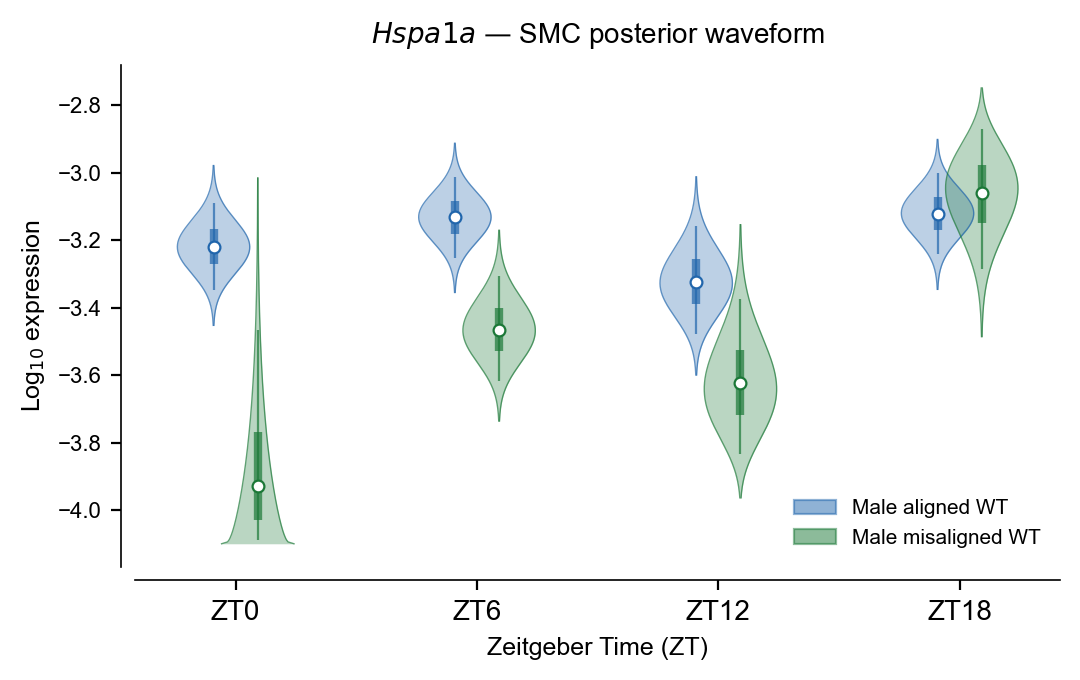

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

GENE = "Hspa1a"
ZT = np.array([0, 6, 12, 18])
N_GRID = 200  # density evaluation points per violin
VIOLIN_WIDTH = 1.8

conditions = {
    "male aligned bmal1-control": {"color": "#2166ac", "label": "Male aligned WT", "offset": -0.55},
    "male misaligned bmal1-control": {"color": "#1b7837", "label": "Male misaligned WT", "offset": 0.55},
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 0.6,
})

fig, ax = plt.subplots(figsize=(5.5, 3.5), dpi=200)

for condition, style in conditions.items():
    alpha_df, beta_df, minmax_df = load_waveform_params("SMC", condition)
    dists, log_min, log_max = get_gene_distributions(GENE, alpha_df, beta_df, minmax_df)
    color = style["color"]
    offset = style["offset"]

    for i, dist in enumerate(dists):
        # Closed-form quantiles
        q5, q25, q50, q75, q95 = [prop_to_log10_expr(dist.ppf(q), log_min, log_max)
                                    for q in (0.05, 0.25, 0.50, 0.75, 0.95)]

        # Closed-form density for the violin shape
        p_lo, p_hi = dist.ppf(0.001), dist.ppf(0.999)
        p_grid = np.linspace(p_lo, p_hi, N_GRID)
        density = dist.pdf(p_grid)
        y_grid = prop_to_log10_expr(p_grid, log_min, log_max)

        # Normalize density to desired width
        density_norm = density / density.max() * (VIOLIN_WIDTH / 2)
        x_center = ZT[i] + offset

        ax.fill_betweenx(y_grid, x_center - density_norm, x_center + density_norm,
                         color=color, alpha=0.3, linewidth=0)
        ax.plot(x_center - density_norm, y_grid, color=color, linewidth=0.5, alpha=0.7)
        ax.plot(x_center + density_norm, y_grid, color=color, linewidth=0.5, alpha=0.7)

        # IQR + 90% CI bars
        ax.vlines(x_center, q5, q95, color=color, linewidth=0.8, alpha=0.7)
        ax.vlines(x_center, q25, q75, color=color, linewidth=3.0, alpha=0.7)
        ax.scatter([x_center], [q50], color="white", edgecolor=color, s=18, zorder=4, linewidth=0.8)

# Legend
handles = [
    mpatches.Patch(facecolor=s["color"], alpha=0.5, edgecolor=s["color"], linewidth=0.8, label=s["label"])
    for s in conditions.values()
]
ax.legend(handles=handles, frameon=False, fontsize=7.5, loc="lower right")

ax.set_xlabel("Zeitgeber Time (ZT)", fontsize=9)
ax.set_ylabel("Log$_{10}$ expression", fontsize=9)
ax.set_title(f"$\\it{{{GENE}}}$ — SMC posterior waveform", fontsize=10, pad=8)
ax.set_xticks(ZT)
ax.set_xticklabels([f"ZT{t}" for t in ZT], fontsize=8)
ax.tick_params(axis="y", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
plt.tight_layout()
plt.show()

## Notes

- All quantiles and densities are computed in closed form from the Beta distribution (no Monte Carlo sampling required).
- The thick bar shows the interquartile range (25th–75th percentile), thin whiskers the 90% credible interval (5th–95th), and the white dot the median.
- Expression values are in log$_{10}$(UMI fraction) space — i.e., each cell's UMI counts divided by its library size, then log$_{10}$-transformed.
- The `de_novo_metrics.tsv` file in each condition directory contains hypothesis testing results, including a `confident_cycler` column indicating whether each gene passes all rhythmicity thresholds.
- Available cell types: SMC, Fibroblast, EC, Macrophage (major); SMC0–SMC4 (subtypes).
- Available conditions: `male aligned bmal1-control`, `female aligned bmal1-control`, `male aligned bmal1-ko`, `female aligned bmal1-ko`, `male misaligned bmal1-control`, `female misaligned bmal1-control`.